<a href="https://colab.research.google.com/github/aminul01-g/Clustering_Iris_Dataset/blob/main/Clustering_Assignment_Iris_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
# Load Dataset

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [ ]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
# Basic EDA (Exploratory Data Analysis)
print("Basice Info: ")
print(df.info())
print("\n")
print("Description: ")
print(df.describe())

Basice Info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB
None


Description: 
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max          

In [ ]:
# Check for the missing value

df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0


In [ ]:
# Scale the features

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)

In [ ]:
scaled_df = pd.DataFrame(scaled_features, columns=df.columns)

In [ ]:
scaled_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


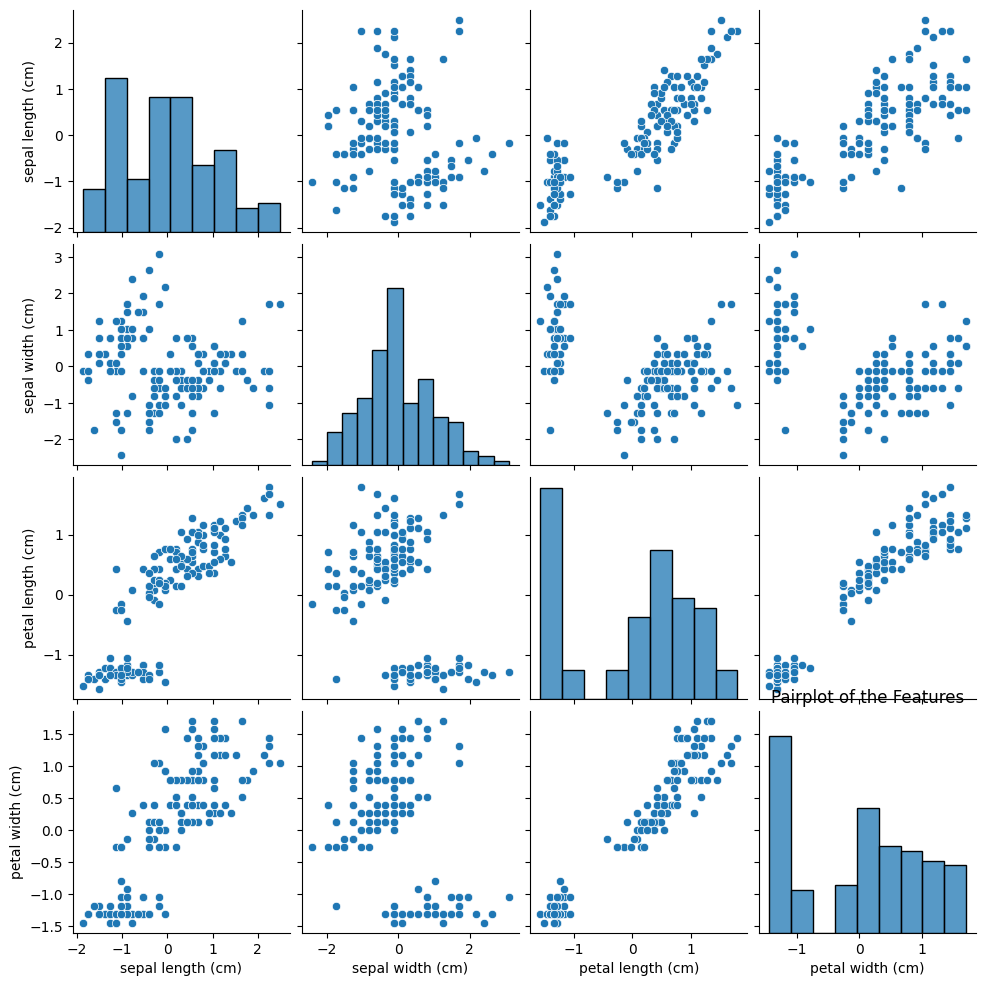

In [ ]:
# pairplot

sns.pairplot(scaled_df)
plt.title("Pairplot of the Features")
plt.show()

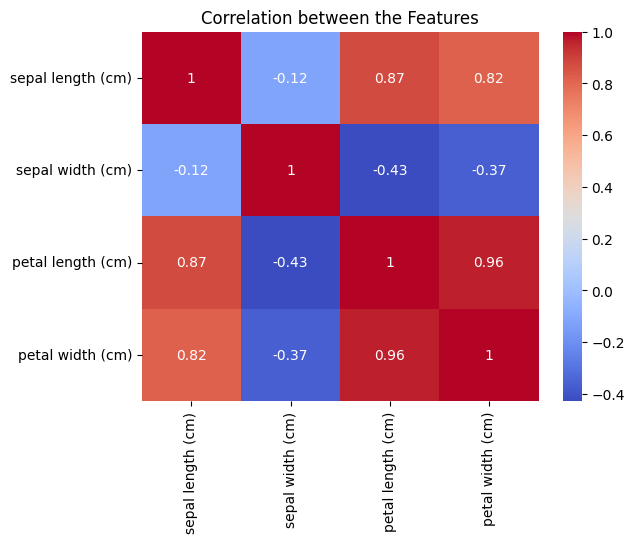

In [ ]:
# Correaltion between the features

sns.heatmap(scaled_df.corr(), annot=True, cmap = "coolwarm")
plt.title("Correlation between the Features")
plt.show()

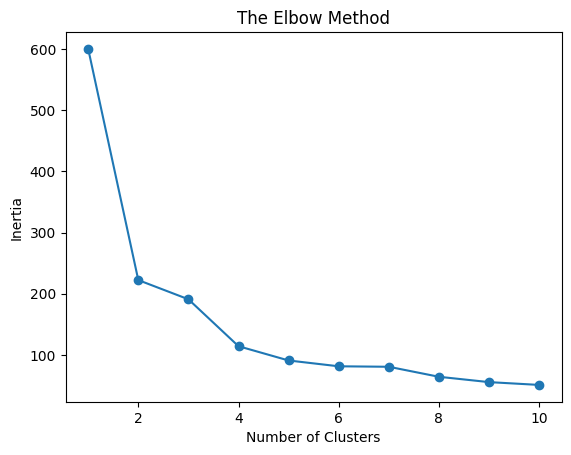

In [ ]:
# Choosing K: The Elbow Method
from sklearn.cluster import KMeans

inertia = []
k = range(1,11)

for i in k:
    kmeans = KMeans(n_clusters = i, random_state = 42)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

plt.plot(k, inertia, marker = "o")
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters = 3, random_state = 42)
kmeans_labels = kmeans.fit(scaled_df)

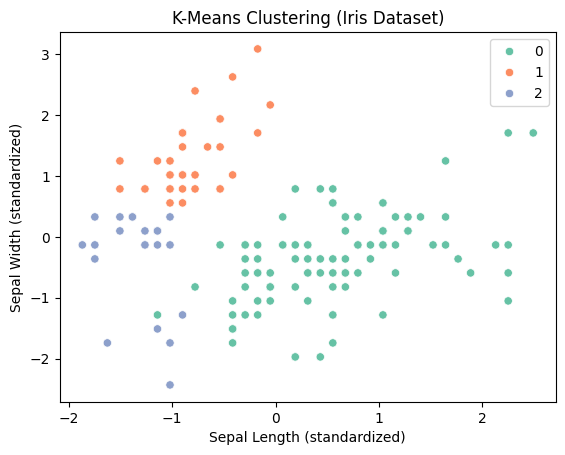

In [ ]:
# visualization

sns.scatterplot(x = scaled_df["sepal length (cm)"], y = scaled_df["sepal width (cm)"], hue = kmeans.labels_, palette= 'Set2')
plt.title('K-Means Clustering (Iris Dataset)')
plt.xlabel('Sepal Length (standardized)')
plt.ylabel('Sepal Width (standardized)')
plt.show()

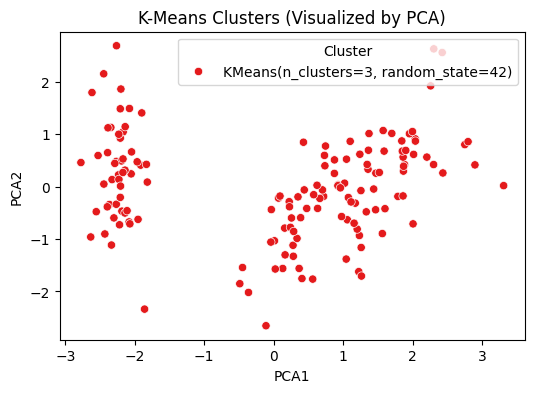

In [ ]:
from sklearn.decomposition import PCA

# Reduce dimensions to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_df)

# Prepare DataFrame
X_pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
X_pca_df['Cluster'] = kmeans_labels

# Plot
plt.figure(figsize=(6, 4))
sns.scatterplot(data=X_pca_df, x='PCA1', y='PCA2', hue='Cluster', palette='Set1')
plt.title('K-Means Clusters (Visualized by PCA)')
plt.show()


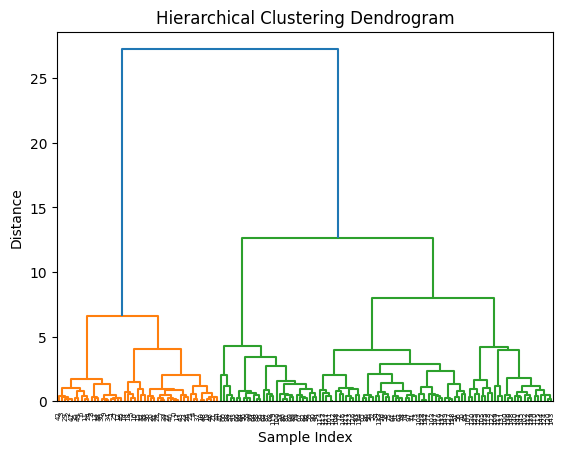

In [ ]:
# Hierarchical Clustering

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster


linked = linkage(scaled_df, 'ward')
dendrogram(linked)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

In [ ]:
# Assign clusters

hc_labels = fcluster(linked, 3, criterion='maxclust')

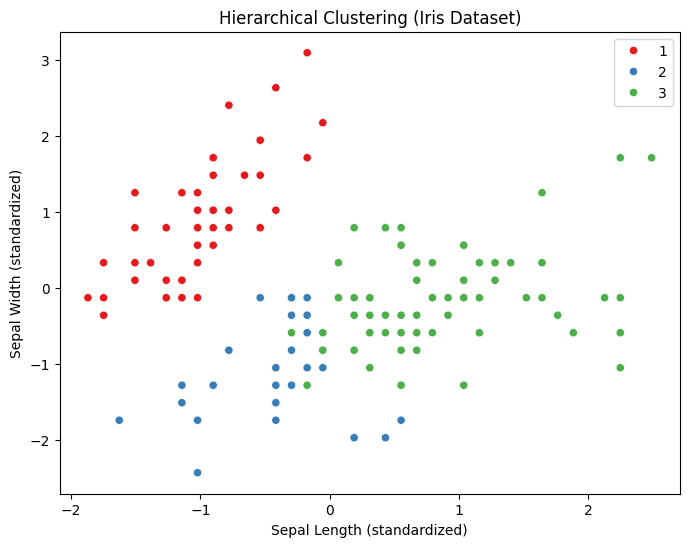

In [ ]:
# visualize cluster

plt.figure(figsize=(8,6))
sns.scatterplot(x=scaled_df['sepal length (cm)'], y=scaled_df['sepal width (cm)'], hue=hc_labels, palette='Set1')
plt.title('Hierarchical Clustering (Iris Dataset)')
plt.xlabel('Sepal Length (standardized)')
plt.ylabel('Sepal Width (standardized)')
plt.show()

In [ ]:
# DBSCAN

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_df)

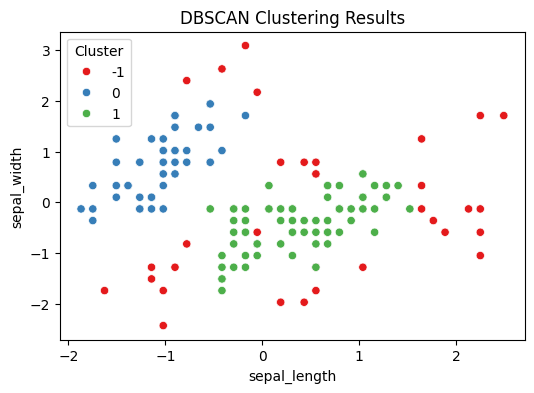

In [ ]:
# plotting with renamed columns
X_temp = scaled_df[['sepal length (cm)', 'sepal width (cm)']].copy()
X_temp.columns = ['sepal_length', 'sepal_width']

X_temp['Cluster'] = dbscan_labels

plt.figure(figsize=(6, 4))
sns.scatterplot(data=X_temp, x='sepal_length', y='sepal_width', hue='Cluster', palette='Set1')
plt.title('DBSCAN Clustering Results')
plt.show()

In [ ]:
from sklearn.metrics import adjusted_rand_score, confusion_matrix

true_labels = iris.target # 0, 1, 2 (actual species)

# Adjusted Rand Index
print('Adjusted Rand Index for KMeans:',adjusted_rand_score(true_labels, kmeans.labels_))
print("Adjusted Rand Index for Hierarchical:", adjusted_rand_score(true_labels, hc_labels))
print("Adjusted Rand Index for DBSCAN:", adjusted_rand_score(true_labels, dbscan_labels))

# Confusion Matrix
import pandas as pd
pd.crosstab(true_labels, hc_labels, rownames=['True'], colnames=['Predicted'])

Adjusted Rand Index for KMeans: 0.432804702527474
Adjusted Rand Index for Hierarchical: 0.6153229932145449
Adjusted Rand Index for DBSCAN: 0.4420986685885924


Predicted,1,2,3
True,,,
0,49,1,0
1,0,27,23
2,0,2,48
